<a href="https://colab.research.google.com/github/niharika070706/BookMyStyApp/blob/main/Employee_Purchase_Prediction_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Purchase Prediction: Machine Learning Tutorial

Code and output are shown one after another for every step.

**How to run in Colab:** click **Runtime > Run all**. In Step 2 a **Choose Files** button appears. Select `employee_data_500_records_practice.csv` from your computer, wait for the upload to finish, and the notebook continues.

## Step 1: Install & Import Libraries

In [2]:
# ============================================================
# STEP 1: Install & Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

**Explanation:** Imports the libraries for data handling (pandas, numpy), plotting (matplotlib, seaborn) and machine learning (scikit-learn).

## Step 2: Load Dataset (Upload from your computer)

In [3]:
# ============================================================
# STEP 2: Load Dataset (Upload from your computer)
# ============================================================
from google.colab import files
uploaded = files.upload()   # choose employee_data_500_records_practice.csv

data = pd.read_csv("employee_data_500_records_practice.csv")
print(data.head())

Saving employee_data_500_records_practice.csv to employee_data_500_records_practice (1).csv
   EmployeeID   Age  Gender  Department  Experience   Salary  Purchased
0           1  25.0  Female          IT          20  69557.0          1
1           2  46.0    Male          IT          14  68621.0          0
2           3  24.0    Male   Marketing          13  48835.0          0
3           4  40.0    Male  Operations          31  94373.0          1
4           5  44.0    Male       Sales          29  93274.0          1


**Explanation:** Opens a file-upload button. Choose `employee_data_500_records_practice.csv`, then the data is loaded into a DataFrame and the first five records are displayed.

## Step 3: Understand Dataset

In [4]:
# ============================================================
# STEP 3: Understand Dataset
# ============================================================
print("Dataset Shape:")
print(data.shape)

Dataset Shape:
(500, 7)


In [5]:
print("\nColumns")
print(data.columns)


Columns
Index(['EmployeeID', 'Age', 'Gender', 'Department', 'Experience', 'Salary',
       'Purchased'],
      dtype='object')


In [ ]:
print("\nDataset Information")
print(data.info())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmployeeID  500 non-null    int64  
 1   Age         485 non-null    float64
 2   Gender      490 non-null    object 
 3   Department  500 non-null    object 
 4   Experience  500 non-null    int64  
 5   Salary      490 non-null    float64
 6   Purchased   500 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB
None


In [ ]:
print("\nStatistical Summary")
print(data.describe())


Statistical Summary
       EmployeeID         Age  Experience         Salary   Purchased
count  500.000000  485.000000  500.000000     490.000000  500.000000
mean   250.500000   40.583505   17.990000   69238.606122    0.504000
std    144.481833   11.552778   10.721558   22820.179541    0.500485
min      1.000000   21.000000    0.000000   25000.000000    0.000000
25%    125.750000   30.000000    9.000000   50394.750000    0.000000
50%    250.500000   41.000000   18.000000   69282.500000    1.000000
75%    375.250000   50.000000   27.250000   86962.750000    1.000000
max    500.000000   60.000000   37.000000  120000.000000    1.000000


In [ ]:
print("\nData Types")
print(data.dtypes)


Data Types
EmployeeID      int64
Age           float64
Gender         object
Department     object
Experience      int64
Salary        float64
Purchased       int64
dtype: object


**Explanation:** Helps us understand the number of rows and columns, column names, missing values (compare *Non-Null Count* with 500), data types and the statistical summary.

## Step 4: Check Missing Values

In [ ]:
# ============================================================
# STEP 4: Check Missing Values
# ============================================================
print(data.isnull().sum())

EmployeeID     0
Age           15
Gender        10
Department     0
Experience     0
Salary        10
Purchased      0
dtype: int64


**Explanation:** Shows the number of missing values in every column.

## Step 5: Handle Missing Values

In [ ]:
# ============================================================
# STEP 5: Handle Missing Values
# ============================================================
num_imputer = SimpleImputer(strategy='mean')
data[['Age', 'Salary']] = num_imputer.fit_transform(data[['Age', 'Salary']])

cat_imputer = SimpleImputer(strategy='most_frequent')
data[['Gender']] = cat_imputer.fit_transform(data[['Gender']])

**Explanation:** Numerical values (`Age`, `Salary`) are filled with the **mean**. The categorical value (`Gender`) is filled with the **most frequent** value.

In [ ]:
# Check: missing values after filling (should all be 0)
print(data.isnull().sum())

EmployeeID    0
Age           0
Gender        0
Department    0
Experience    0
Salary        0
Purchased     0
dtype: int64


## Step 6: Remove Duplicate Records

In [ ]:
# ============================================================
# STEP 6: Remove Duplicate Records
# ============================================================
data = data.drop_duplicates()
print(data.shape)

(500, 7)


**Explanation:** Removes repeated records. If the shape stays `(500, 7)`, there were no duplicates.

## Step 7A: Label Encoding

In [ ]:
# ============================================================
# STEP 7A: Label Encoding
# ============================================================
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])
# Example: Male → 1, Female → 0

**Explanation:** Converts `Gender` from text to numbers. Example: Female -> 0, Male -> 1.

In [ ]:
# Check: Gender is now numeric
print(data['Gender'].value_counts())

Gender
1    270
0    230
Name: count, dtype: int64


## Step 7B: One Hot Encoding

In [ ]:
# ============================================================
# STEP 7B: One Hot Encoding
# ============================================================
data = pd.get_dummies(data, columns=['Department'], drop_first=True)

**Explanation:** Converts `Department` into binary (0/1) columns. `drop_first=True` drops one column (`Department_HR`) to avoid redundant information.

In [ ]:
# Check: Department became separate 0/1 columns
print(data.head())

   EmployeeID   Age  Gender  Experience   Salary  Purchased  Department_IT  \
0           1  25.0       0          20  69557.0          1           True   
1           2  46.0       1          14  68621.0          0           True   
2           3  24.0       1          13  48835.0          0          False   
3           4  40.0       1          31  94373.0          1          False   
4           5  44.0       1          29  93274.0          1          False   

   Department_Marketing  Department_Operations  Department_Sales  
0                 False                  False             False  
1                 False                  False             False  
2                  True                  False             False  
3                 False                   True             False  
4                 False                  False              True  


## Step 8: Select Features and Target

In [ ]:
# ============================================================
# STEP 8: Select Features and Target
# ============================================================
X = data.drop("Purchased", axis=1)
y = data["Purchased"]

**Explanation:** `X` holds the independent variables (inputs) and `y` holds the target variable (`Purchased`).

In [ ]:
# Check: what went into X and y
print('X columns:', list(X.columns))
print('X shape:', X.shape, '| y shape:', y.shape)

X columns: ['EmployeeID', 'Age', 'Gender', 'Experience', 'Salary', 'Department_IT', 'Department_Marketing', 'Department_Operations', 'Department_Sales']
X shape: (500, 9) | y shape: (500,)


## Step 9: Train-Test Split

In [ ]:
# ============================================================
# STEP 9: Train-Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Explanation:** 80% of the data is used for training and 20% for testing.

In [ ]:
# Check: size of each split
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)

X_train: (400, 9) | X_test: (100, 9)
y_train: (400,) | y_test: (100,)


## Step 10A: Standard Scaling

In [ ]:
# ============================================================
# STEP 10A: Standard Scaling
# ============================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Explanation:** Standardization: `Z = (X - mean) / standard deviation`. The scaler learns from the training data only and is then applied to the test data.

In [ ]:
# Check: scaled training data has mean ~0 and std ~1
print('Mean:', X_train.mean(axis=0).round(2))
print('Std :', X_train.std(axis=0).round(2))

Mean: [-0. -0.  0.  0.  0. -0.  0. -0. -0.]
Std : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 11: Logistic Regression Model

In [ ]:
# ============================================================
# STEP 11: Logistic Regression Model
# ============================================================
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**Explanation:** Trains a Logistic Regression model on the processed training data.

## Step 12: Prediction

In [ ]:
# ============================================================
# STEP 12: Prediction
# ============================================================
y_pred = model.predict(X_test)
print(y_pred)

[1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 0 0 0 1 1
 0 0 1 0 0 1 1 0 1 0 1 0 0 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 0 1 0 0
 1 0 1 1 0 1 0 1 1 0 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0]


**Explanation:** The model predicts `Purchased` (0 or 1) for every employee in the test set.

## Step 13: Accuracy

In [ ]:
# ============================================================
# STEP 13: Accuracy
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy)

Accuracy = 0.71


**Explanation:** Accuracy = correct predictions / total predictions.

## Step 14: Confusion Matrix

[[34 15]
 [14 37]]


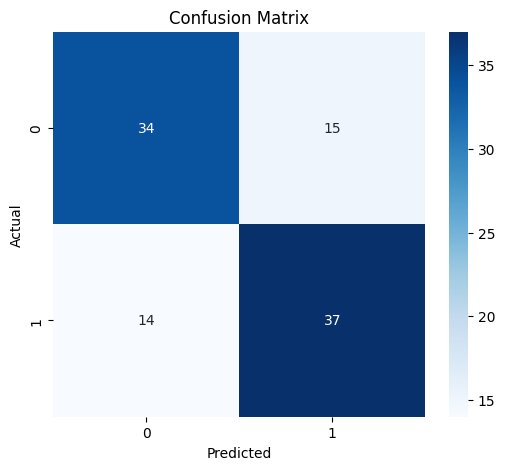

In [ ]:
# ============================================================
# STEP 14: Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Explanation:** Shows True Negative (top-left), False Positive (top-right), False Negative (bottom-left) and True Positive (bottom-right).

## Step 15: Classification Report

In [ ]:
# ============================================================
# STEP 15: Classification Report
# ============================================================
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.69      0.70        49
           1       0.71      0.73      0.72        51

    accuracy                           0.71       100
   macro avg       0.71      0.71      0.71       100
weighted avg       0.71      0.71      0.71       100



**Explanation:** Provides precision, recall, F1 score and support for each class.

## Step 16: Precision

In [ ]:
# ============================================================
# STEP 16: Precision
# ============================================================
precision = precision_score(y_test, y_pred)
print("Precision =", precision)

Precision = 0.7115384615384616


**Explanation:** Precision = TP / (TP + FP). Of all employees predicted as *Purchased*, how many really purchased?

## Step 17: Recall

In [ ]:
# ============================================================
# STEP 17: Recall
# ============================================================
recall = recall_score(y_test, y_pred)
print("Recall =", recall)

Recall = 0.7254901960784313


**Explanation:** Recall = TP / (TP + FN). Of all employees who really purchased, how many did the model find?

## Step 18: F1 Score

In [ ]:
# ============================================================
# STEP 18: F1 Score
# ============================================================
f1 = f1_score(y_test, y_pred)
print("F1 Score =", f1)

F1 Score = 0.7184466019417476


**Explanation:** F1 score is the harmonic mean of precision and recall.

## Step 19: ROC Curve

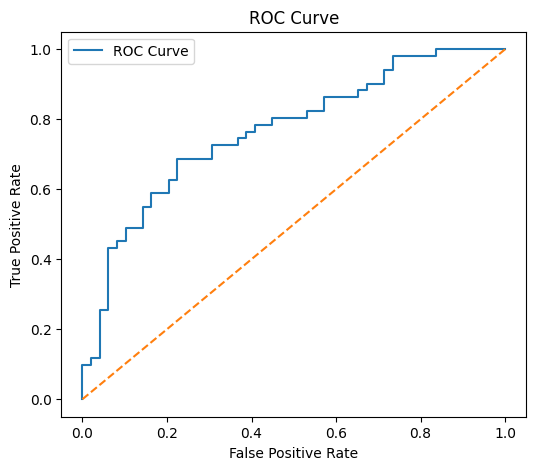

In [ ]:
# ============================================================
# STEP 19: ROC Curve
# ============================================================
probability = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probability)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Explanation:** The ROC curve shows the trade-off between true positive rate and false positive rate. The dashed line is random guessing, so the closer the blue curve is to the top-left corner, the better.

## Step 20: ROC-AUC Score

In [ ]:
# ============================================================
# STEP 20: ROC-AUC Score
# ============================================================
auc = roc_auc_score(y_test, probability)
print("ROC AUC Score =", auc)

ROC AUC Score = 0.765906362545018


**Explanation:** AUC is the area under the ROC curve. 0.5 means random guessing and 1.0 means a perfect model.

## Step 21: Feature Importance

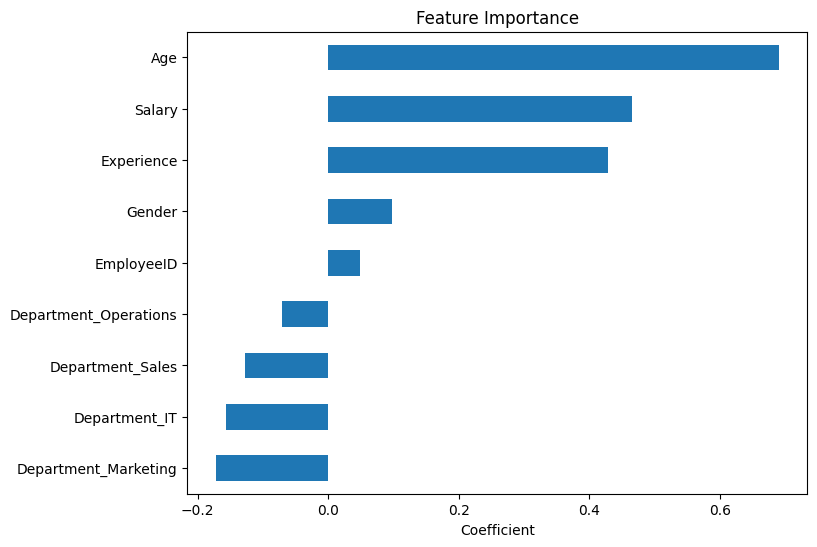

In [ ]:
# ============================================================
# STEP 21: Feature Importance
# ============================================================
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.show()

**Explanation:** Each bar is the model's coefficient for that feature. Positive values push towards `Purchased = 1` and negative values push towards `Purchased = 0`.

## Step 22: Pair Plot

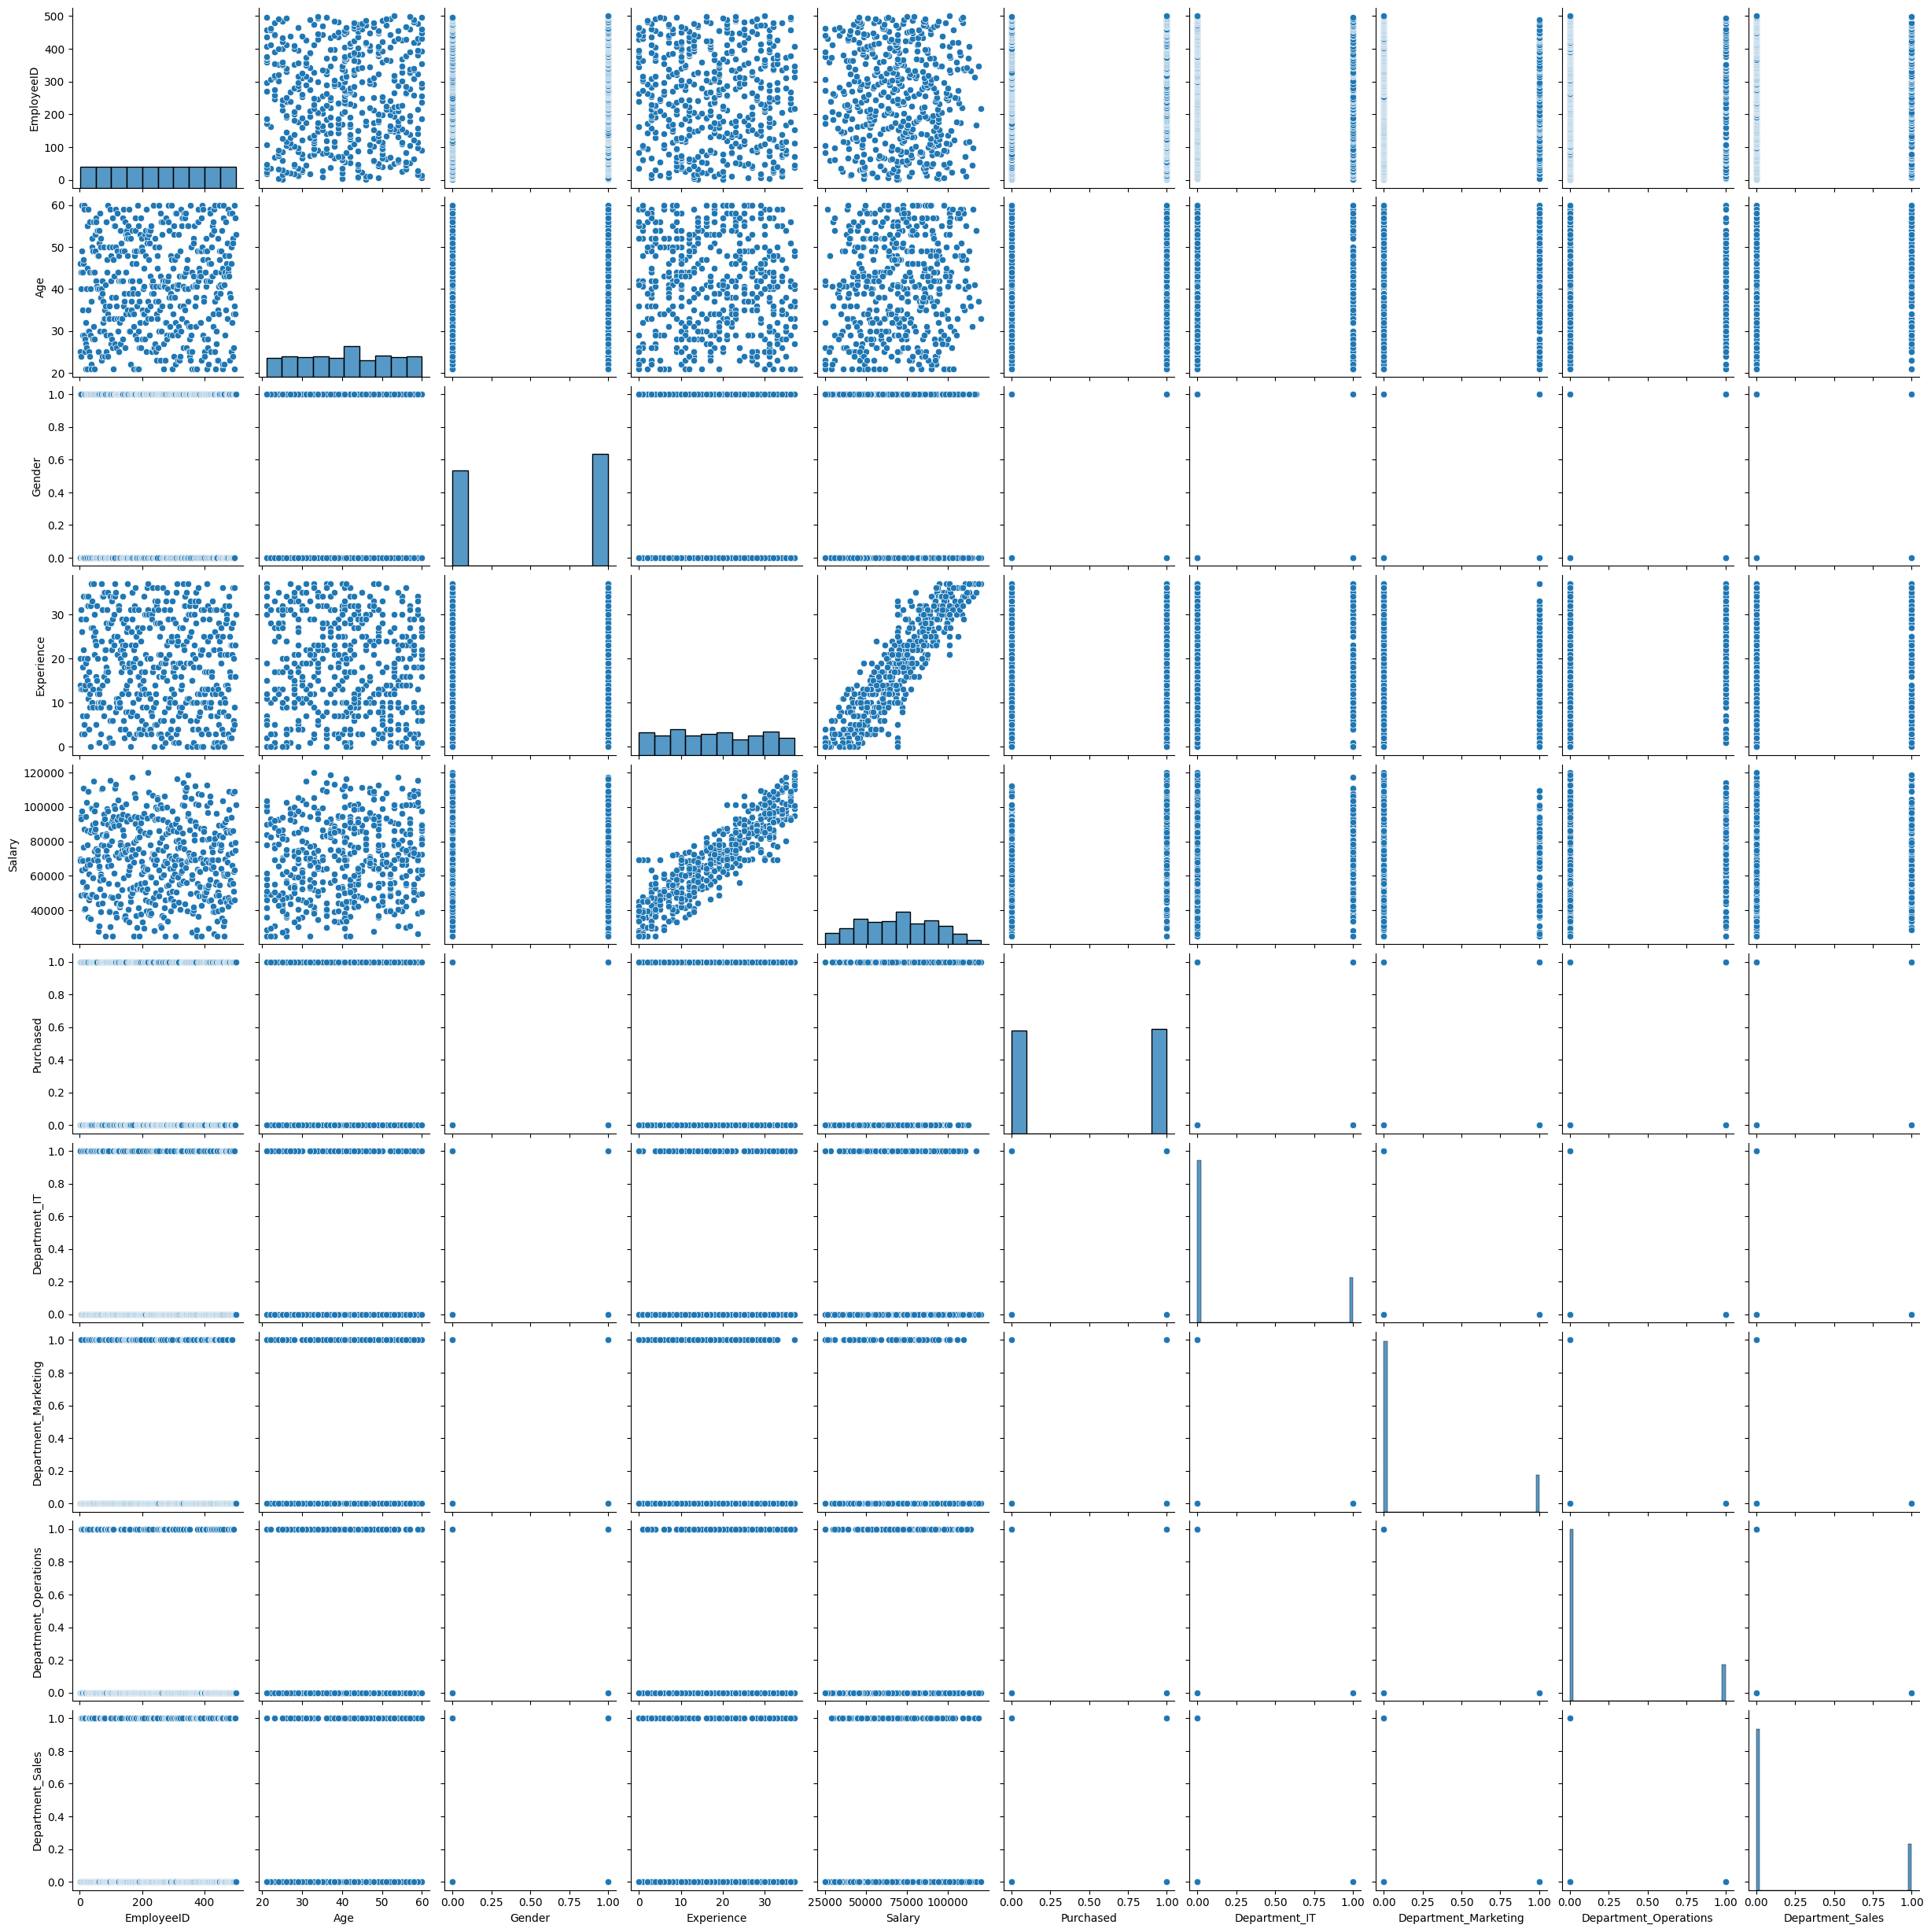

In [ ]:
# ============================================================
# STEP 22: Pair Plot
# ============================================================
sns.pairplot(data)
plt.show()

**Explanation:** Shows the relationship between every pair of columns.

## Step 23: Correlation Heatmap

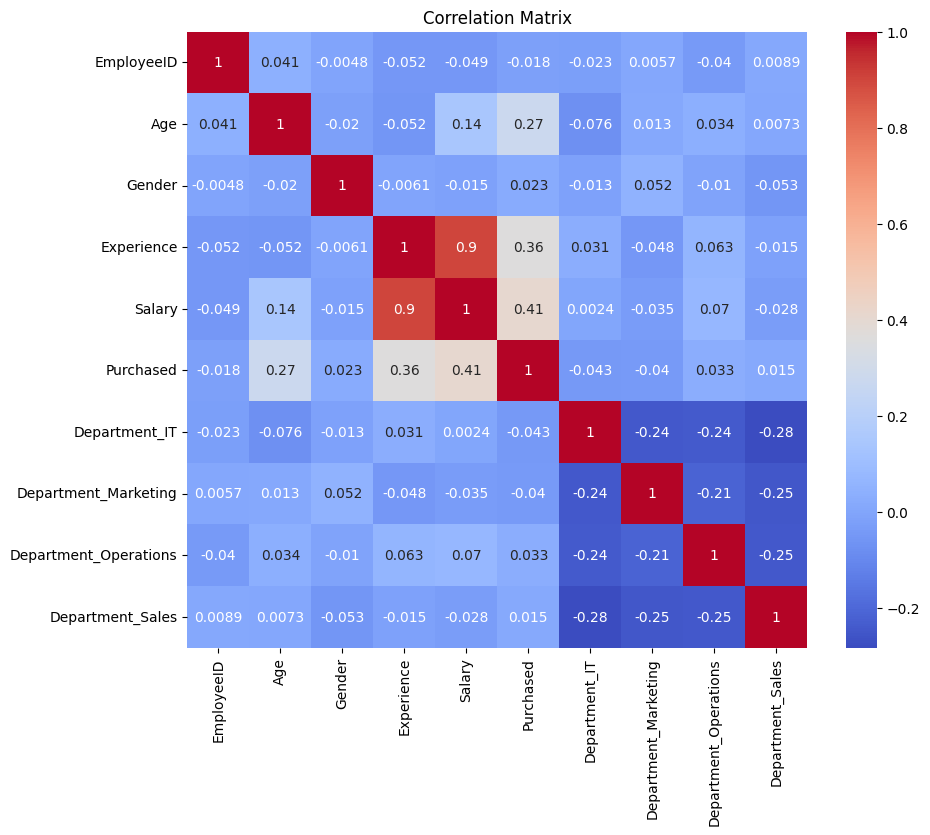

In [ ]:
# ============================================================
# STEP 23: Correlation Heatmap
# ============================================================
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Explanation:** Shows how strongly every pair of columns is related (-1 to +1). Check the `Purchased` row for the features most related to the target.

## Step 24: Distribution Plot

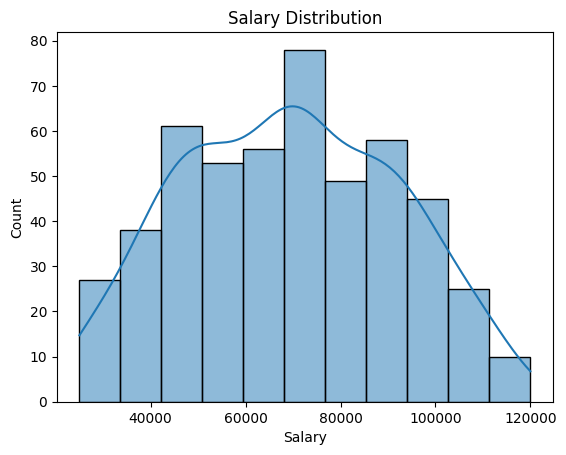

In [ ]:
# ============================================================
# STEP 24: Distribution Plot
# ============================================================
sns.histplot(data["Salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

**Explanation:** Shows how salary values are spread across employees. The smooth line is the estimated distribution.